In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("./data")

avg_patronage = pd.read_csv(
    DATA_PATH / 
    "monthly_average_patronage_by_day_type_and_by_mode.csv"
)

monthly_patronage = pd.read_csv(
    DATA_PATH /
    "monthly_public_transport_patronage_by_mode.csv"
)
print(avg_patronage.shape)
print(monthly_patronage.shape)

(4450, 7)
(99, 10)


In [2]:
# Keep only bus modes
bus_avg = avg_patronage[
    avg_patronage["Mode"].isin(
        [
            "MetroBus",
            "RegionalBus"
        ]
    )
].copy()


# Remove unnecessary column
bus_avg.drop(
    columns=["Month_name"],
    inplace=True
)


# Create monthly date index
bus_avg["Date"] = pd.to_datetime(
    dict(
        year=bus_avg["Year"],
        month=bus_avg["Month"],
        day=1
    )
)


# Check result
bus_avg.head()

,Year,Month,Day_of_week,Day_type,Mode,Pax_daily,Date
0,2018,1,Friday,School Holiday Weekday,MetroBus,268350,2018-01-01
2,2018,1,Friday,School Holiday Weekday,RegionalBus,21550,2018-01-01
5,2018,1,Monday,Normal Weekday,MetroBus,308450,2018-01-01
7,2018,1,Monday,Normal Weekday,RegionalBus,22600,2018-01-01
10,2018,1,Monday,School Holiday Weekday,MetroBus,298500,2018-01-01


In [3]:
bus_avg = (
    bus_avg
    .groupby(
        [
            "Year",
            "Month",
            "Date",
            "Day_of_week",
            "Day_type",
            "Mode"
        ],
        as_index=False
    )
    ["Pax_daily"]
    .mean()
)

bus_avg[
    [
        "Date",
        "Day_of_week",
        "Day_type",
        "Mode"
    ]
].duplicated().sum()

bus_avg.head()

,Year,Month,Date,Day_of_week,Day_type,Mode,Pax_daily
0,2018,1,2018-01-01,Friday,School Holiday Weekday,MetroBus,268350.0
1,2018,1,2018-01-01,Friday,School Holiday Weekday,RegionalBus,21550.0
2,2018,1,2018-01-01,Monday,Normal Weekday,MetroBus,308450.0
3,2018,1,2018-01-01,Monday,Normal Weekday,RegionalBus,22600.0
4,2018,1,2018-01-01,Monday,School Holiday Weekday,MetroBus,298500.0


In [4]:
bus_avg_grouped = (
    bus_avg
    .groupby(
        [
            "Year",
            "Month",
            "Date",
            "Day_of_week",
            "Mode"
        ],
        as_index=False
    )
    ["Pax_daily"]
    .mean()
)

bus_avg_grouped.head()

,Year,Month,Date,Day_of_week,Mode,Pax_daily
0,2018,1,2018-01-01,Friday,MetroBus,268350.0
1,2018,1,2018-01-01,Friday,RegionalBus,21550.0
2,2018,1,2018-01-01,Monday,MetroBus,303475.0
3,2018,1,2018-01-01,Monday,RegionalBus,22875.0
4,2018,1,2018-01-01,Saturday,MetroBus,154100.0


# Monthly_patronage

In [5]:
bus_monthly = monthly_patronage[
    [
        "Year",
        "Month",
        "Metropolitan bus",
        "Regional bus"
    ]
].copy()

bus_monthly["Date"] = pd.to_datetime(
    dict(
        year=bus_monthly["Year"],
        month=bus_monthly["Month"],
        day=1
    )
)

# Add total bus
bus_monthly["Total_bus"] = (
    bus_monthly["Metropolitan bus"]
    +
    bus_monthly["Regional bus"]
)

bus_monthly.head()

,Year,Month,Metropolitan bus,Regional bus,Date,Total_bus
0,2018,1,7568547,721229,2018-01-01,8289776
1,2018,2,10487311,1118494,2018-02-01,11605805
2,2018,3,11528895,1224816,2018-03-01,12753711
3,2018,4,9592750,946218,2018-04-01,10538968
4,2018,5,11263486,1258704,2018-05-01,12522190


# data quality checks


In [6]:
# Average dataset
print(bus_avg.shape)

print(bus_avg.isnull().sum())

print(bus_avg.duplicated().sum())

bus_avg.describe()

# Monthly datset
print(bus_monthly.shape)

print(bus_monthly.isnull().sum())

print(bus_monthly.duplicated().sum())

bus_monthly.describe()



(1780, 7)
Year           0
Month          0
Date           0
Day_of_week    0
Day_type       0
Mode           0
Pax_daily      0
dtype: int64
0
(99, 6)
Year                0
Month               0
Metropolitan bus    0
Regional bus        0
Date                0
Total_bus           0
dtype: int64
0


,Year,Month,Metropolitan bus,Regional bus,Date,Total_bus
count,99.000000,99.000000,9.900000e+01,9.900000e+01,99,9.900000e+01
mean,2021.636364,6.363636,8.253926e+06,9.597872e+05,2022-01-30 15:01:49.090909,9.213714e+06
min,2018.000000,1.000000,1.507175e+06,2.273420e+05,2018-01-01 00:00:00,1.734517e+06
25%,2020.000000,3.000000,7.211975e+06,8.398010e+05,2020-01-16 12:00:00,8.100490e+06
50%,2022.000000,6.000000,8.809813e+06,9.857310e+05,2022-02-01 00:00:00,9.731991e+06
75%,2024.000000,9.000000,1.009440e+07,1.120144e+06,2024-02-15 12:00:00,1.131685e+07
max,2026.000000,12.000000,1.208214e+07,1.287180e+06,2026-03-01 00:00:00,1.336932e+07
std,2.396658,3.506421,2.496425e+06,2.310276e+05,NaN,2.706280e+06


In [7]:
# -- Check date rage
print(
    bus_avg_grouped["Date"].min(),
    bus_avg_grouped["Date"].max()
)


print(
    bus_monthly["Date"].min(),
    bus_monthly["Date"].max()
)

2018-01-01 00:00:00 2026-03-01 00:00:00
2018-01-01 00:00:00 2026-03-01 00:00:00


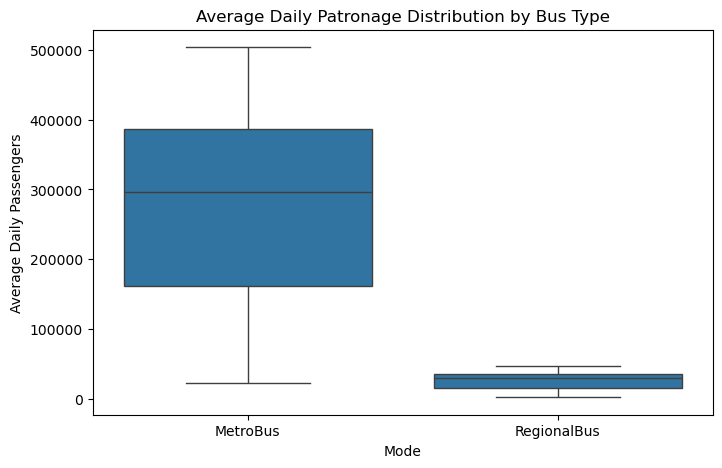

In [8]:
#  --- metros bus vs regional bus comparison

plt.figure(figsize=(8,5))
sns.boxplot(
    data=bus_avg_grouped,
    x="Mode",
    y="Pax_daily"
)

plt.title(
    "Average Daily Patronage Distribution by Bus Type"
)

plt.ylabel(
    "Average Daily Passengers"
)

plt.show()

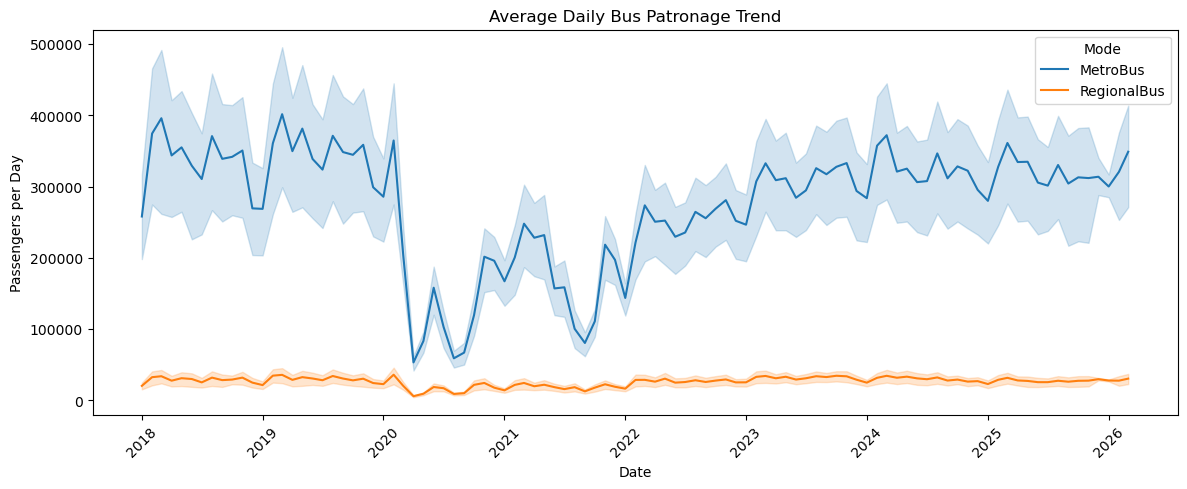

In [9]:
# -- average daily apssenger trend

plt.figure(figsize=(14,5))
sns.lineplot(
    data=bus_avg_grouped,
    x="Date",
    y="Pax_daily",
    hue="Mode"
)
plt.title(
    "Average Daily Bus Patronage Trend"
)
plt.ylabel(
    "Passengers per Day"
)
plt.xticks(rotation=45)
plt.show()

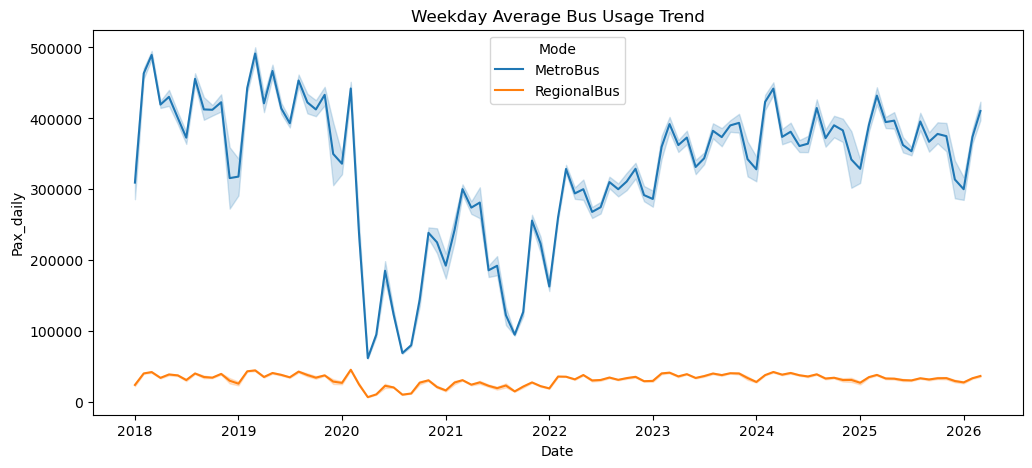

In [10]:
# weekday behaviour
weekday_data = bus_avg_grouped[
    bus_avg_grouped["Day_of_week"].isin(
        [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday"
        ]
    )
]
plt.figure(figsize=(12,5))

sns.lineplot(
    data=weekday_data,
    x="Date",
    y="Pax_daily",
    hue="Mode"
)

plt.title(
    "Weekday Average Bus Usage Trend"
)

plt.show()

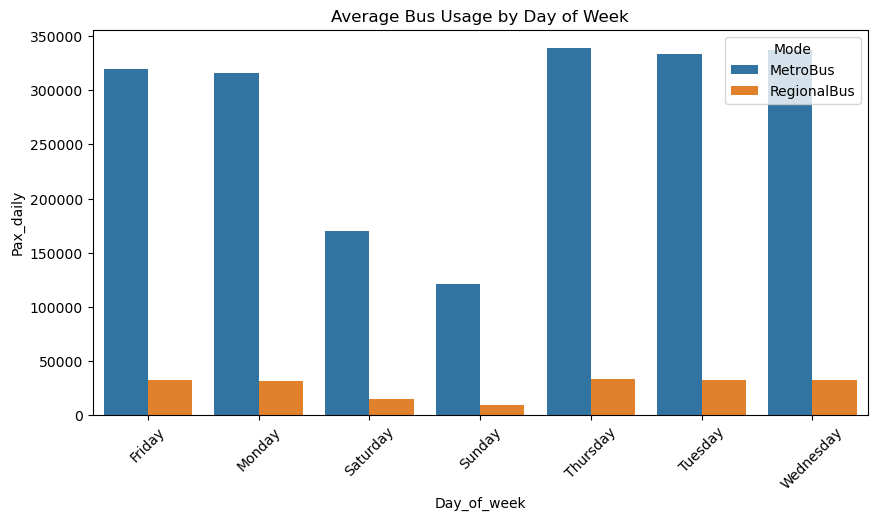

In [11]:
# Weekday distribution
weekday_average = (
    bus_avg_grouped
    .groupby(
        [
            "Day_of_week",
            "Mode"
        ]
    )
    ["Pax_daily"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_average,
    x="Day_of_week",
    y="Pax_daily",
    hue="Mode"
)

plt.title(
    "Average Bus Usage by Day of Week"
)

plt.xticks(rotation=45)

plt.show()

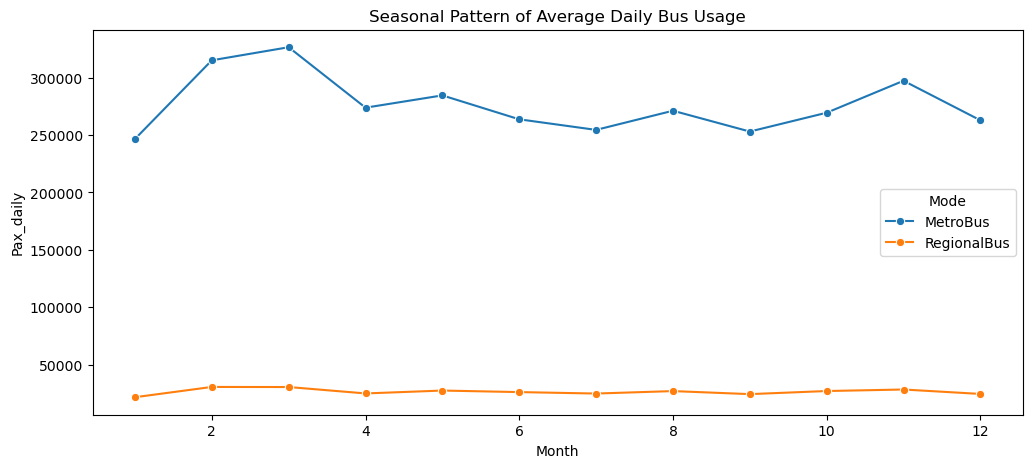

In [12]:
# Does bus usage change by month

monthly_pattern = (
    bus_avg_grouped
    .groupby(
        [
            "Month",
            "Mode"
        ]
    )
    ["Pax_daily"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Pax_daily",
    hue="Mode",
    marker="o"
)


plt.title(
    "Seasonal Pattern of Average Daily Bus Usage"
)

plt.show()

# MOnthly dataset eda

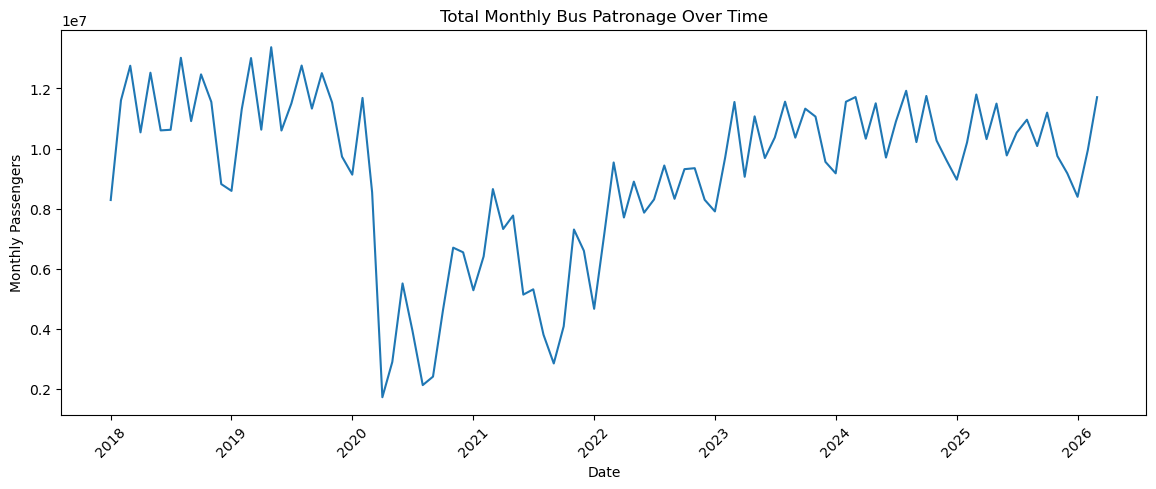

In [13]:
#-- total month bus patronage over time
plt.figure(figsize=(14,5))
sns.lineplot(
    data=bus_monthly,
    x="Date",
    y="Total_bus"
)
plt.title(
    "Total Monthly Bus Patronage Over Time"
)

plt.ylabel(
    "Monthly Passengers"
)

plt.xticks(rotation=45)

plt.show()

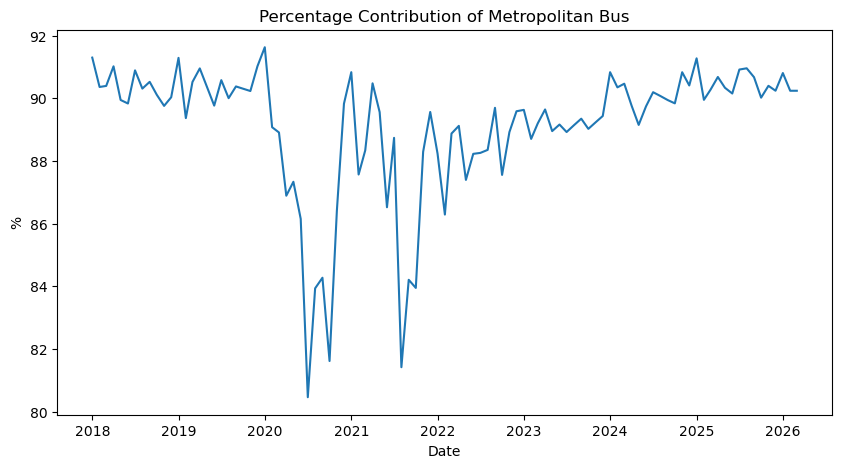

In [14]:
#-- metro ve regional contribution
bus_monthly["Metro_percentage"] = (
    bus_monthly["Metropolitan bus"]
    /
    bus_monthly["Total_bus"]
    *
    100
)


bus_monthly["Regional_percentage"] = (
    bus_monthly["Regional bus"]
    /
    bus_monthly["Total_bus"]
    *
    100
) 
plt.figure(figsize=(10,5))

sns.lineplot(
    data=bus_monthly,
    x="Date",
    y="Metro_percentage"
)

plt.title(
    "Percentage Contribution of Metropolitan Bus"
)

plt.ylabel("%")

plt.show()

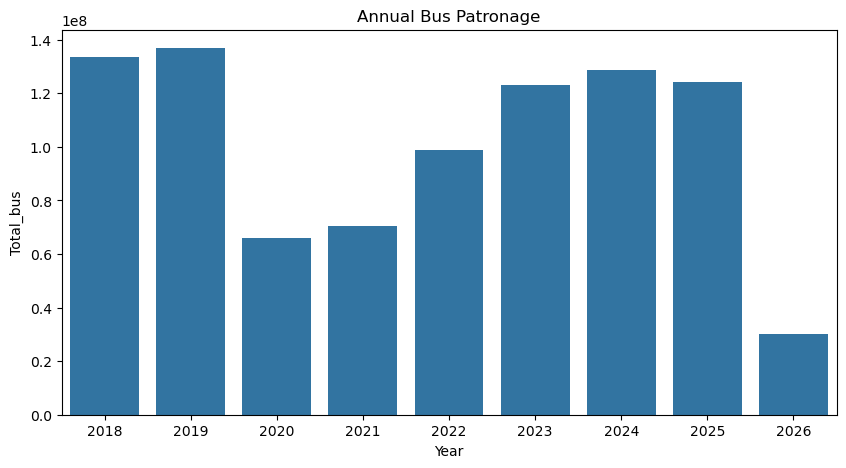

In [15]:
# -- yearly comparison
yearly_bus = (
    bus_monthly
    .groupby("Year")
    [
        [
            "Metropolitan bus",
            "Regional bus",
            "Total_bus"
        ]
    ]
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_bus,
    x="Year",
    y="Total_bus"
)

plt.title(
    "Annual Bus Patronage"
)

plt.show()

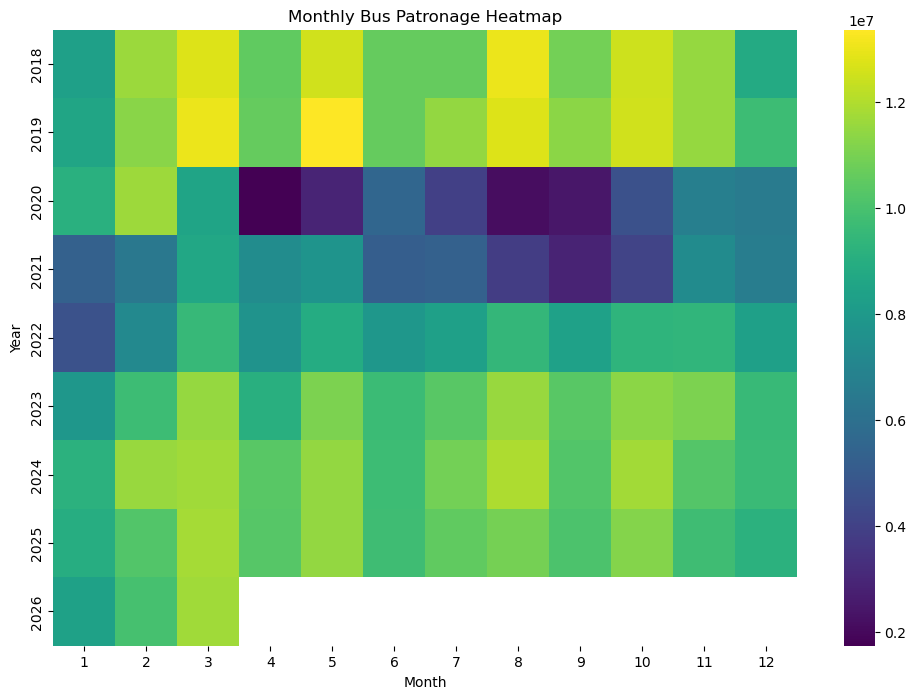

In [16]:
#-- monthly heatmap
heatmap_data = bus_monthly.pivot(
    index="Year",
    columns="Month",
    values="Total_bus"
)


plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="viridis"
)

plt.title(
    "Monthly Bus Patronage Heatmap"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Year"
)

plt.show()

# Save dataset

In [17]:
# 1. Define and create output directory
PROCESSED_DATA_PATH = Path("./processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# 2. Dictionary of final datasets and their intended export filenames
final_datasets = {
    "bus_avg": (bus_avg, "bus_avg.csv"),
    "bus_avg_grouped": (bus_avg_grouped, "bus_avg_grouped.csv"),
    "bus_monthly": (bus_monthly, "bus_monthly.csv")
}

# 3. Export datasets and display required inspection metrics
for dataset_name, (df, filename) in final_datasets.items():
    # Save processed CSV
    file_path = PROCESSED_DATA_PATH / filename
    df.to_csv(file_path, index=False)
    
    # Display requested structural information
    print("=" * 60)
    print(f" DATASET: {dataset_name} (Saved to: {file_path})")
    print("=" * 60)
    print(df.columns.to_list())
    print("\n--- Head (3) ---")
    print(df.head(3))
    print("\n--- Info ---")
    df.info()
    print("\n" + "\n")

 DATASET: bus_avg (Saved to: processed_data\bus_avg.csv)
['Year', 'Month', 'Date', 'Day_of_week', 'Day_type', 'Mode', 'Pax_daily']

--- Head (3) ---
   Year  Month       Date Day_of_week                Day_type         Mode  \
0  2018      1 2018-01-01      Friday  School Holiday Weekday     MetroBus   
1  2018      1 2018-01-01      Friday  School Holiday Weekday  RegionalBus   
2  2018      1 2018-01-01      Monday          Normal Weekday     MetroBus   

   Pax_daily  
0   268350.0  
1    21550.0  
2   308450.0  

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         1780 non-null   int64         
 1   Month        1780 non-null   int64         
 2   Date         1780 non-null   datetime64[us]
 3   Day_of_week  1780 non-null   str           
 4   Day_type     1780 non-null   str           
 5   Mode         1780 non